In [1]:
from flonacomldft.md_utils import get_is1, get_is2, run_molecular_dynamics, get_path
from ase.io.trajectory import Trajectory 
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from flonacomldft.dft_utils import C, R

from ase.visualize import view

plt.rcParams.update({'font.size': 14})

In [2]:
n=2000
is1 = Trajectory(get_path()+'ag6_is1_lcao.traj')[n:]
is2 = Trajectory(get_path()+'ag6_is2_lcao.traj')[n:]

traj = Trajectory('ag6_is_.traj', 'w')

for atoms in is1[::10]:
    traj.write(atoms)

for atoms in is2[::10]:
    traj.write(atoms)

traj.close()

print('Dataset dimension: ', len(traj))

Dataset dimension:  602


In [3]:
threshold = int(len(traj)/2)
threshold

301

In [4]:
def get_energies(trajectory, indexes):
    u = []
    for index_ in indexes:
        u.append(trajectory[index_.int()].get_potential_energy())
    return torch.tensor(u).float()

def run_mcmc(trajectory, steps, Nchains):
    
    # Shuffle all the configurations
    samples = torch.randperm(len(trajectory))
    
    #Random init state
    init = torch.randint(0, len(trajectory), (Nchains,))
    u_init = get_energies(trajectory, init)
    
    chains = [init, ]
    accs = []
    
    T=300
    kb = 8.617333262e-5
    beta = 1/(kb*T)
    
    for step in range(steps):
        i = torch.randint(0, len(trajectory), (Nchains,))
        u = get_energies(trajectory, i)

        ratio = torch.exp(-beta*torch.tensor(u.clone().detach() - u_init.clone().detach()).float())

        acc = torch.rand_like(ratio) < torch.min(ratio, torch.ones_like(ratio))

        i[~acc] = init[~acc]
        u[~acc] = u_init[~acc]

        chains.append(i.clone())
        accs.append(acc)
        init = i.clone()
        u_init = u.clone()
   
    return torch.stack(chains), torch.stack(accs)

In [5]:
traj = Trajectory('ag6_is_.traj')
chains, accs = run_mcmc(traj, 200, 150)

/tmp/ipykernel_140784/2966384437.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ratio = torch.exp(-beta*torch.tensor(u.clone().detach() - u_init.clone().detach()).float())


In [6]:
indexes_counts = [torch.unique_consecutive(chain, return_counts=True) for chain in chains.T]

Text(0.5, 0, 'chains')

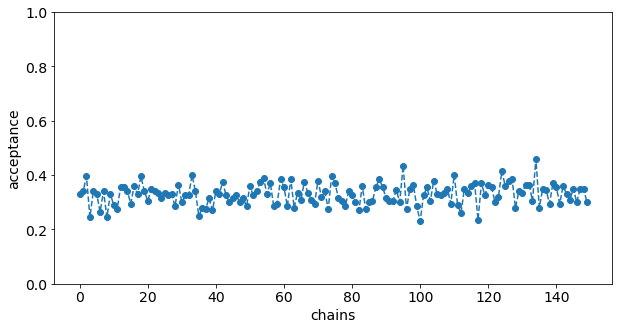

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(accs.float().mean(axis=0).numpy(), 'o--');
plt.ylim(0, 1)
plt.ylabel('acceptance')
plt.xlabel('chains')

Text(0.5, 0, 'steps')

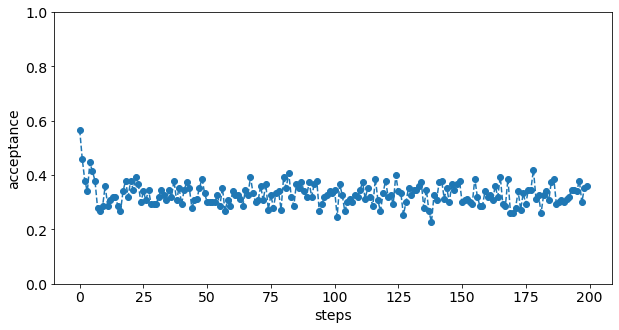

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(accs.float().mean(axis=1), 'o--')
plt.ylim(0,1)
plt.ylabel('acceptance')
plt.xlabel('steps')

In [9]:
is2_p = (chains>=threshold).int().sum()
total_p = (chains>=threshold).int().size()[0]*(chains>=threshold).int().size()[1]

In [10]:
p2 = is2_p/total_p
p1 = (total_p-is2_p)/total_p

In [11]:
print('Populations: ')
print('Planar isomer: %.2f'% p1.numpy())
print('3D isomer: %.2f'% p2.numpy())

Populations: 
Planar isomer: 0.96
3D isomer: 0.04


In [14]:
n = np.random.randint(150)
print('Chain: ', n)
chain_ = indexes_counts[n][0]

CVs = []
for config_ in chain_:
    atom = traj[config_]
    CVs.append(torch.tensor([C(atom), R(atom)]))

Chain:  58


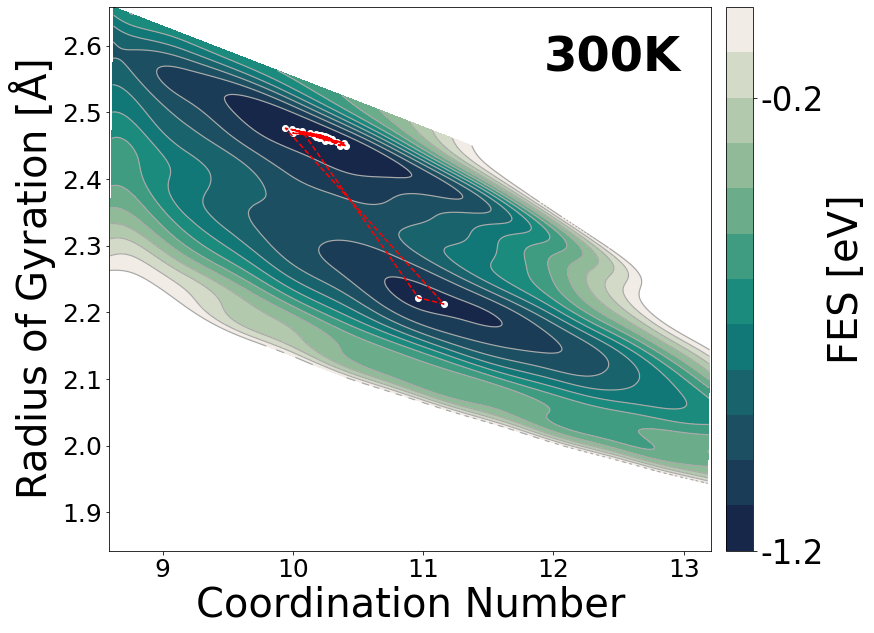

In [15]:
from flonacomldft.dft_utils import plotting_fes_db

ax = plotting_fes_db()
ax.plot(torch.stack(CVs).T[0], torch.stack(CVs).T[1] , 'o', c='white');
ax.plot(torch.stack(CVs).T[0], torch.stack(CVs).T[1] , '--', c='r');

In [16]:
colors = []
for config in chains.T[n]:
    if config>=threshold:
        colors.append('r')
    else:
        colors.append('b')

Text(0.5, 0, 'Steps')

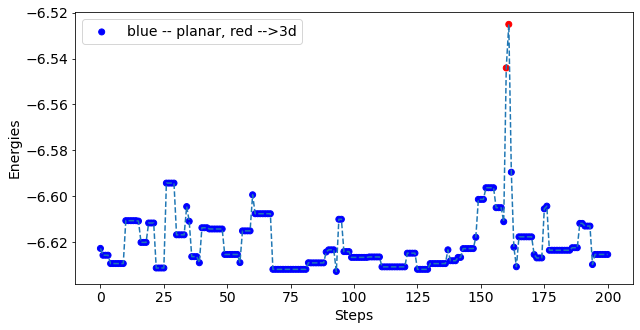

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(get_energies(traj, chains.T[n]), '--')
plt.scatter(np.arange(0, chains.T[n].size()[0], 1), get_energies(traj, chains.T[n]), c=colors, label='blue -- planar, red -->3d')
plt.legend()
plt.ylabel('Energies')
plt.xlabel('Steps')

Text(0, 0.5, 'jumps')

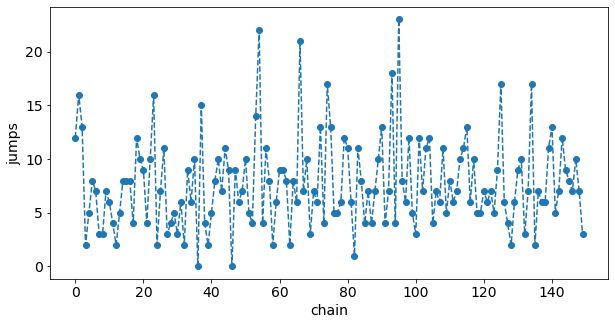

In [18]:
jumps = []
for i in range(150):
    jumps.append((chains>=threshold).int()[:, i].unique_consecutive().size()[0]-1)
    
plt.figure(figsize=(10, 5))
plt.plot(jumps, 'o--')
plt.xlabel('chain')
plt.ylabel('jumps')

In [ ]:
#from ase.visualize import view
#view(traj[chains.T[n][75]])